### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [5]:
wiki.invoke("What is LangGraph?")

'Page: List of unsolved problems in mathematics\nSummary: Many mathematical problems have been stated but not yet solved. These problems come from many areas of mathematics, such as theoretical physics, computer science, algebra, analysis, combinatorics, algebraic, differential, discrete and Euclidean geometries, graph theory, group theory, model theory, number theory, set theory, Ramsey theory, dynamical systems, and partial differential equations. Some problems belong to more than one discipline'

In [6]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [8]:
# Tavily Search
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [9]:
tavily.invoke("What is the recent news about Agentic AI?")

[{'title': 'Adopting agentic AI in 2026: 5 things you can do right now | UiPath',
  'url': 'https://www.uipath.com/blog/ai/adopting-agentic-ai-2026-things-you-can-do-right-now',
  'content': 'And you’re not alone. Many enterprises are still figuring out how to adopt agentic AI in a way that actually scales and delivers measurable business impact. Recent studies from Accenture and Wipro show that 70-80% of agentic initiatives haven’t made it to enterprise scale.\n\nBut that’s not stopping organizations from pressing ahead. According to NTT, Inc. and WSJ Intelligence, 68% of global CEOs plan to increase AI investment in the next two years.\n\nThe good news is that agentic AI success isn’t a distant vision. UiPath customers like Pearson, Allegis Global Solutions, and SunExpress are already seeing meaningful results. [...] ###### Why agentic\n\n###### Why agentic\n\nWhy agentic\n\nCustomer Stories\n\nCustomer stories\n\nGather insight, read success stories, and more.\n\nEvents\n\nBlog\n\nG

In [10]:
# Combine all tools in a list

tools = [arxiv, wiki, tavily]

In [27]:
# Initialize the llm model

from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    api_key=os.getenv("GROQ_API_KEY"),
)

llm_with_tools=llm.bind_tools(tools)

In [28]:
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage


response = llm_with_tools.invoke([HumanMessage(content="What is the recent news about Agentic AI?")])


In [29]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about recent news on Agentic AI. I need to figure out which tool to use here. The available tools are arxiv, wikipedia, and tavily_search_results_json.\n\nArxiv is for academic papers, which might be too technical and not the best for recent news. Wikipedia is good for general information but might not have the latest updates. Tavily is described as a search engine optimized for current events, so that seems like the right choice here. The user wants recent news, so using tavily_search_results_json with the query "recent news about Agentic AI" should provide the most up-to-date and relevant results. Let me make sure the parameters are correct. The function requires a query, which I have. I\'ll structure the tool call accordingly.\n', 'tool_calls': [{'id': 'g7896vjq9', 'function': {'arguments': '{"query":"recent news about Agentic AI"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, r

In [30]:
response.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent news about Agentic AI'},
  'id': 'g7896vjq9',
  'type': 'tool_call'}]

In [31]:
# State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

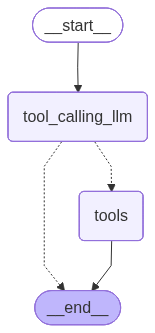

In [32]:
### Entire Chatbot with LangGraph

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Node definitions
def tool_calling_llm(state: State):
    return {'messages':[llm_with_tools.invoke(state['messages'])]}

## Build the graph
builder = StateGraph(State)

# add nodes
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))  #tools = [arxiv, wiki, tavily]

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)
builder.add_edge("tools", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
messages = graph.invoke({'messages': [HumanMessage(content="1706.03762")]})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (n0xxhtt9q)
 Call ID: n0xxhtt9q
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [35]:
messages = graph.invoke({'messages': [HumanMessage(content="Provide me top 10 recent news about Agentic AI")]})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

Provide me top 10 recent news about Agentic AI
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (8kxa1r9sq)
 Call ID: 8kxa1r9sq
  Args:
    query: top 10 recent news about Agentic AI
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025", "url": "https://www.crescendo.ai/news/latest-ai-news-and-updates", "content": "Date: February 2, 2026\n\nSummary: Snowflake and OpenAI have entered into a landmark $200 million strategic partnership aimed at accelerating the deployment of \"agentic AI\" for corporate enterprises. The deal integrates OpenAI’s most advanced models directly into Snowflake’s Data Cloud, allowing businesses to build autonomous agents that can securely analyze proprietary data, execute

In [37]:
messages = graph.invoke({'messages': [HumanMessage(content="What is Machine Learning?")]})

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

What is Machine Learning?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (rc7sbbrgj)
 Call ID: rc7sbbrgj
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches 
